###### 品質モンスター巡回レポートを作ろう

In [22]:
%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Meiryo"

os.makedirs("input", exist_ok=True)
os.makedirs("output", exist_ok=True)

df_sample = pd.DataFrame(
    [
        ["2026/06/01", "MELMB", "LCM-A", "点灯不良", 10000, 3],
        ["2026/06/01", "WSE", "LCM-B", "外観不良", 8000, 5],
        ["2026/06/02", "GSE", "LCM-C", "ショート", 12000, 1],
        ["2026/06/02", "MELMB", "LCM-A", "点灯不良", 11000, 8],
        ["2026/06/03", "ISE", "LCM-D", "コネクタ浮き", 9000, 2],
        ["2026/06/03", "WSE", "LCM-B", "異物混入", 7000, 7],
        ["2026/06/04", "MELAC", "LCM-E", "はんだ不良", 15000, 4],
        ["2026/06/04", "GSE", "LCM-C", "ショート", 10000, 6],
        ["2026/06/05", "MELMB", "LCM-A", "点灯不良", 9000, 10],
        ["2026/06/05", "ISE", "LCM-D", "コネクタ浮き", 8500, 0],
        ["2026/06/06", "WSE", "LCM-B", "外観不良", 9000, np.nan],
        ["2026/06/06", "MELAC", "LCM-E", "はんだ不良", 14000, 9],
    ],
    columns=["date", "site", "product", "defect", "production", "defects"],
)

df_sample.to_csv("input/quality_monster_patrol.csv", index=False, encoding="utf-8-sig")
df = pd.read_csv("input/quality_monster_patrol.csv", encoding="utf-8-sig")
print(df.head())

         date   site product  defect  production  defects
0  2026/06/01  MELMB   LCM-A    点灯不良       10000      3.0
1  2026/06/01    WSE   LCM-B    外観不良        8000      5.0
2  2026/06/02    GSE   LCM-C    ショート       12000      1.0
3  2026/06/02  MELMB   LCM-A    点灯不良       11000      8.0
4  2026/06/03    ISE   LCM-D  コネクタ浮き        9000      2.0


In [23]:
df.isna().sum()

date          0
site          0
product       0
defect        0
production    0
defects       1
dtype: int64

In [24]:
df[["production", "defects"]].describe()

,production,defects
count,12.000000,11.000000
mean,10208.333333,5.000000
std,2406.981638,3.316625
min,7000.000000,0.000000
25%,8875.000000,2.500000
50%,9500.000000,5.000000
75%,11250.000000,7.500000
max,15000.000000,10.000000


In [25]:
df_valid = df.dropna(subset=["defects"]).copy()
#print(df_valid)
df_valid["ppm"] = df_valid["defects"] / df["production"] * 1000000
df_valid["ppm"] = df_valid["ppm"].round(1)
#df_valid["ppm"]

In [26]:
df_valid["危険ランク"] = np.where(
    df_valid["ppm"] >= 1000,
    "s級モンスター",
    np.where(
        df_valid["ppm"] >= 500,
        "a級モンスター",
        "通常モンスター"
    )
)

df_sorted = df_valid.sort_values(by="ppm", ascending=False)
#print(df_sorted)
df_danger = df_sorted[df_sorted["危険ランク"] != "通常モンスター"]
#print(df_sorted)
#print(df_danger)

<function matplotlib.pyplot.show(close=None, block=None)>

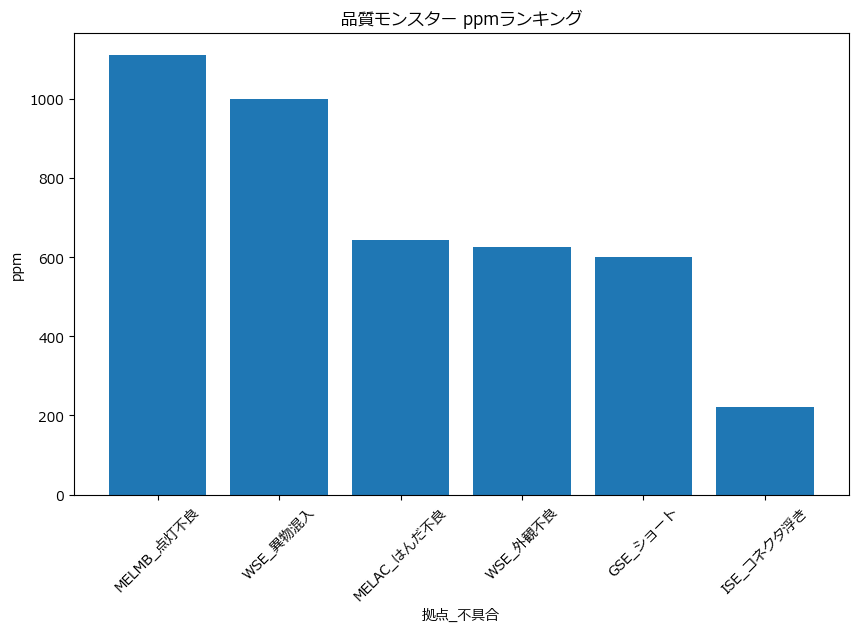

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_sorted["site"] + "_" + df_sorted["defect"], df_sorted["ppm"])

ax.set_title("品質モンスター ppmランキング")
ax.set_xlabel("拠点_不具合")
ax.set_ylabel("ppm")

plt.xticks(rotation=45)
plt.show

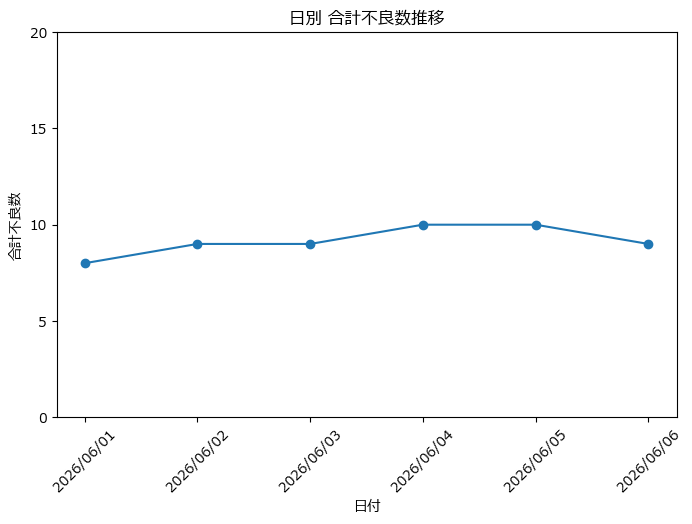

In [45]:
df_daily = df_valid.groupby("date")["defects"].sum()
#print(df_daily)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_daily.index, df_daily.values, marker="o")

ax.set_title("日別 合計不良数推移")
ax.set_xlabel("日付")
ax.set_ylabel("合計不良数")

ax.set_yticks(np.arange(0, 21, 5))
plt.xticks(rotation=45)
plt.show()

In [47]:
df_sorted.to_csv("output/quality_monster_report.csv", index=False, encoding="utf-8-sig")
print("----- df_sorted -----")
print(df_sorted)

df_danger.to_csv("output/danger_monster_report.csv", index=False, encoding="utf-8-sig")
print("----- df_danger -----")
print(df_danger)

----- df_sorted -----
          date   site product  defect  production  defects     ppm    危険ランク
8   2026/06/05  MELMB   LCM-A    点灯不良        9000     10.0  1111.1  s級モンスター
5   2026/06/03    WSE   LCM-B    異物混入        7000      7.0  1000.0  s級モンスター
3   2026/06/02  MELMB   LCM-A    点灯不良       11000      8.0   727.3  a級モンスター
11  2026/06/06  MELAC   LCM-E   はんだ不良       14000      9.0   642.9  a級モンスター
1   2026/06/01    WSE   LCM-B    外観不良        8000      5.0   625.0  a級モンスター
7   2026/06/04    GSE   LCM-C    ショート       10000      6.0   600.0  a級モンスター
0   2026/06/01  MELMB   LCM-A    点灯不良       10000      3.0   300.0  通常モンスター
6   2026/06/04  MELAC   LCM-E   はんだ不良       15000      4.0   266.7  通常モンスター
4   2026/06/03    ISE   LCM-D  コネクタ浮き        9000      2.0   222.2  通常モンスター
2   2026/06/02    GSE   LCM-C    ショート       12000      1.0    83.3  通常モンスター
9   2026/06/05    ISE   LCM-D  コネクタ浮き        8500      0.0     0.0  通常モンスター
----- df_danger -----
          date   site product defect  produc